# **HACKATON**

In [1]:
# MAIN IMPORTS
import sys
import os 
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import torch

## *OG visualisation*

DATASET EXPLORATION

Dataset shape: (73542, 789)
Total recordings: 73,542

PATIENT INFORMATION
Number of patients: 14

Recordings per patient:
  Mean: 5253.0
  Median: 4765.5
  Min: 1407
  Max: 13946

LABEL DISTRIBUTION
Overall:
  Stable (0): 62,614 (85.1%)
  Pre-hospitalization (1): 10,928 (14.9%)

Per patient:
  patient_0000: 6654 stable, 722 pre-hosp (9.8% positive)
  patient_0001: 3985 stable, 818 pre-hosp (17.0% positive)
  patient_0002: 13332 stable, 614 pre-hosp (4.4% positive)
  patient_0003: 2729 stable, 910 pre-hosp (25.0% positive)
  patient_0004: 5223 stable, 397 pre-hosp (7.1% positive)
  patient_0005: 5525 stable, 675 pre-hosp (10.9% positive)
  patient_0006: 2004 stable, 845 pre-hosp (29.7% positive)
  patient_0007: 1135 stable, 272 pre-hosp (19.3% positive)
  patient_0008: 1319 stable, 393 pre-hosp (23.0% positive)
  patient_0009: 2263 stable, 643 pre-hosp (22.1% positive)
  patient_0010: 3763 stable, 965 pre-hosp (20.4% positive)
  patient_0011: 1393 stable, 1309 pre-h

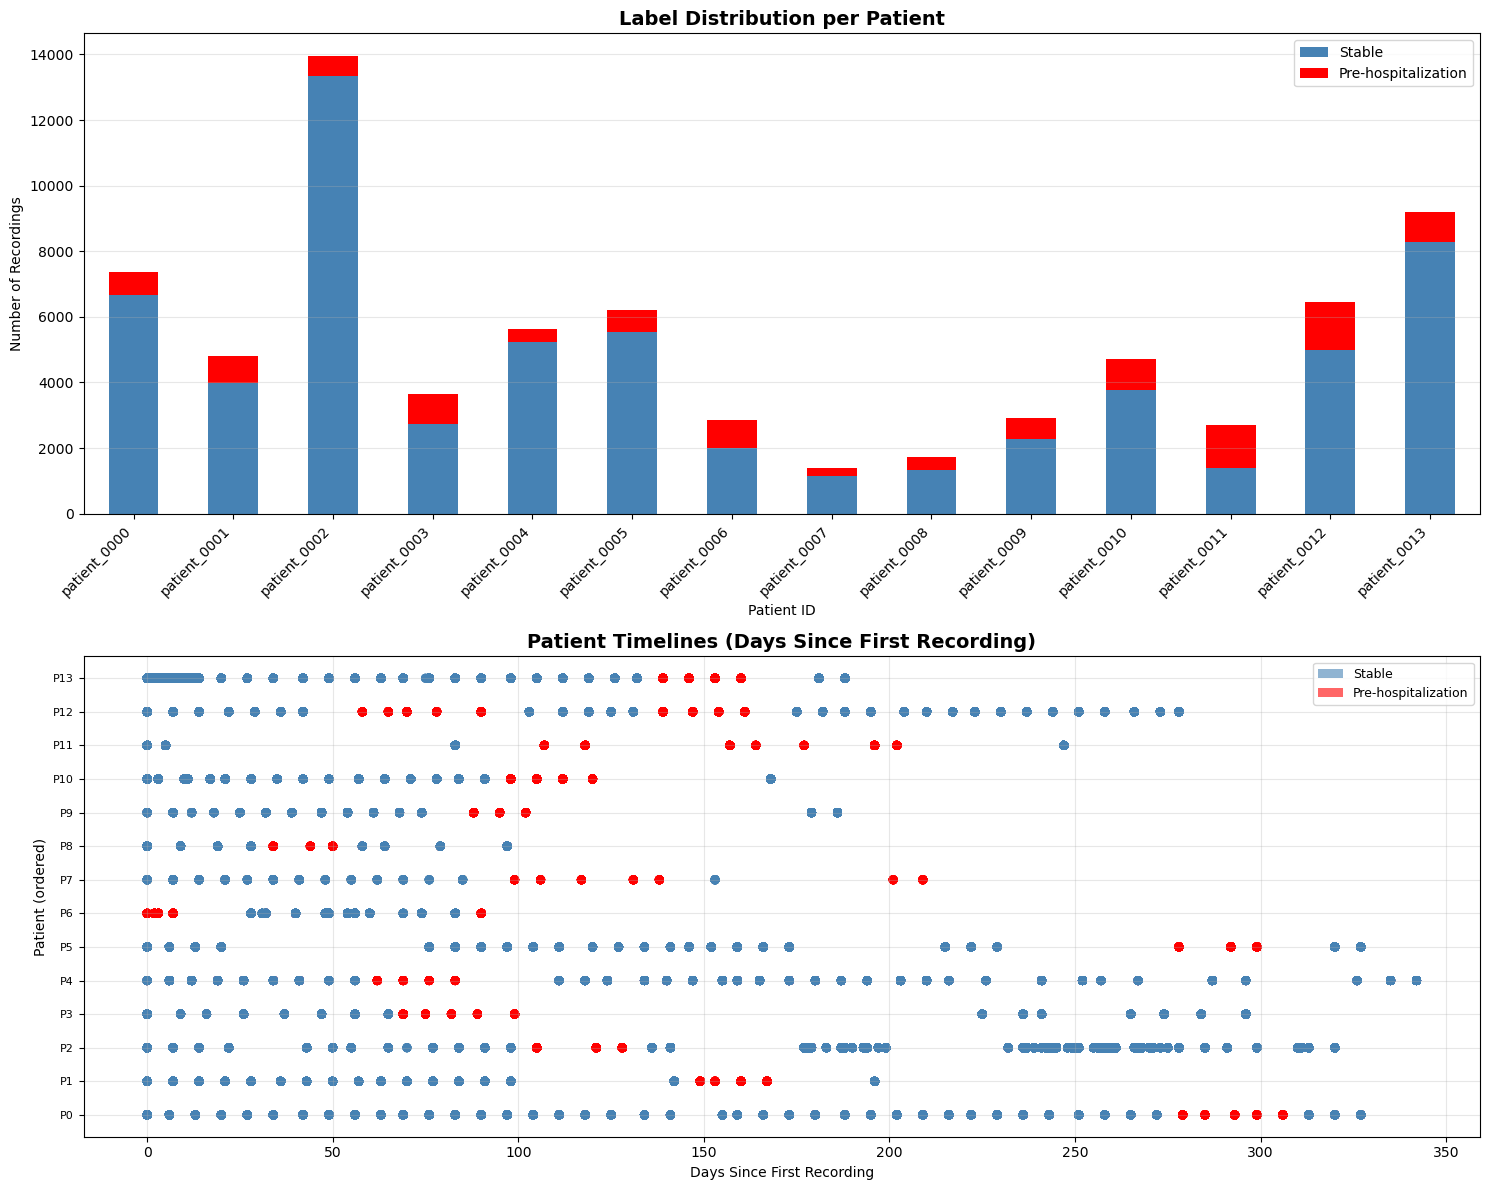


EXPLORATION COMPLETE

Key takeaways:
1. Dataset is imbalanced (more stable than pre-hospitalization recordings)
2. Patients have varying numbers of recordings and follow-up periods
3. Temporal information is available - use it for modeling!
4. Recording dates extracted from recording_id show clear temporal patterns

Next steps:
- Run: python src/train.py (to train baseline model)
- Modify: src/models.py (to improve the embedding model)
- Experiment with temporal modeling and patient-specific features!


In [25]:
"""
Data exploration script.

Run this to understand the dataset structure before diving into modeling.
"""

import sys
import pandas as pd
import matplotlib.pyplot as plt

# Add src to path to import utils
sys.path.insert(0, "src")
from src.utils import extract_date_from_recording_id


def explore_dataset(data_path="data/dataset.parquet"):
    """Explore the dataset and print useful statistics."""

    print("=" * 70)
    print("DATASET EXPLORATION")
    print("=" * 70)

    # Load data
    df = pd.read_parquet(data_path)
    print(f"\nDataset shape: {df.shape}")
    print(f"Total recordings: {len(df):,}")

    # Patient information
    print(f"\n{'=' * 70}")
    print("PATIENT INFORMATION")
    print("=" * 70)
    unique_patients = df["patient_short_id"].unique()
    print(f"Number of patients: {len(unique_patients)}")

    # Recordings per patient
    recordings_per_patient = df.groupby("patient_short_id").size()
    print("\nRecordings per patient:")
    print(f"  Mean: {recordings_per_patient.mean():.1f}")
    print(f"  Median: {recordings_per_patient.median():.1f}")
    print(f"  Min: {recordings_per_patient.min()}")
    print(f"  Max: {recordings_per_patient.max()}")

    # Label distribution
    print(f"\n{'=' * 70}")
    print("LABEL DISTRIBUTION")
    print("=" * 70)
    label_counts = df["label"].value_counts()
    print("Overall:")
    print(f"  Stable (0): {label_counts[0]:,} ({label_counts[0] / len(df) * 100:.1f}%)")
    print(
        f"  Pre-hospitalization (1): {label_counts[1]:,} ({label_counts[1] / len(df) * 100:.1f}%)"
    )

    print("\nPer patient:")
    for patient in sorted(unique_patients):
        patient_df = df[df["patient_short_id"] == patient]
        patient_labels = patient_df["label"].value_counts()
        n_stable = patient_labels.get(0, 0)
        n_prehosp = patient_labels.get(1, 0)
        print(
            f"  {patient}: {n_stable} stable, {n_prehosp} pre-hosp "
            f"({n_prehosp / (n_stable + n_prehosp) * 100:.1f}% positive)"
        )

    # Temporal information
    print(f"\n{'=' * 70}")
    print("TEMPORAL INFORMATION")
    print("=" * 70)

    # Extract dates from recording_id
    df["recording_date"] = extract_date_from_recording_id(df["recording_id"])

    print("\nRecording date range:")
    print(f"  First recording: {df['recording_date'].min().date()}")
    print(f"  Last recording: {df['recording_date'].max().date()}")
    print(
        f"  Total span: {(df['recording_date'].max() - df['recording_date'].min()).days} days"
    )

    print("\nFollow-up period per patient:")
    for patient in sorted(unique_patients):
        patient_df = df[df["patient_short_id"] == patient]
        first_date = patient_df["recording_date"].min()
        last_date = patient_df["recording_date"].max()
        follow_up_days = (last_date - first_date).days
        n_recordings = len(patient_df)
        print(
            f"  {patient}: {follow_up_days} days ({first_date.date()} to {last_date.date()}), {n_recordings} recordings"
        )

    # Feature information
    print(f"\n{'=' * 70}")
    print("FEATURE INFORMATION")
    print("=" * 70)

    metadata_cols = [
        "recording_id",
        "patient_short_id",
        "label",
        "recording_date",  # Added by our extraction
    ]
    feature_cols = [col for col in df.columns if col not in metadata_cols]

    print(f"Number of acoustic features: {len(feature_cols)}")
    print("\nFeature categories:")

    # Count feature types
    feature_types = {}
    for col in feature_cols:
        feature_type = col.split("_")[0]
        feature_types[feature_type] = feature_types.get(feature_type, 0) + 1

    for ftype, count in sorted(feature_types.items()):
        print(f"  {ftype}: {count} features")

    # Check for missing values
    print(f"\n{'=' * 70}")
    print("DATA QUALITY")
    print("=" * 70)

    missing_counts = df[feature_cols].isnull().sum()
    if missing_counts.sum() > 0:
        print(f"Features with missing values: {(missing_counts > 0).sum()}")
        print(f"Total missing values: {missing_counts.sum()}")
    else:
        print("No missing values in features!")

    # Create visualizations
    print(f"\n{'=' * 70}")
    print("GENERATING VISUALIZATIONS")
    print("=" * 70)

    fig, axes = plt.subplots(2, 1, figsize=(15, 12))

    # 1. Label distribution per patient
    ax = axes[0]
    label_dist = df.groupby(["patient_short_id", "label"]).size().unstack(fill_value=0)
    label_dist.plot(kind="bar", stacked=True, ax=ax, color=["steelblue", "red"])
    ax.set_title("Label Distribution per Patient", fontsize=14, fontweight="bold")
    ax.set_xlabel("Patient ID")
    ax.set_ylabel("Number of Recordings")
    ax.legend(["Stable", "Pre-hospitalization"])
    ax.grid(axis="y", alpha=0.3)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")

    # 2. Temporal distribution per patient timeline
    ax = axes[1]
    for i, patient in enumerate(sorted(unique_patients)):
        patient_df = df[df["patient_short_id"] == patient].sort_values("recording_date")
        # Normalize dates to days since first recording for this patient
        first_date = patient_df["recording_date"].min()
        patient_df["days_since_start"] = (
            patient_df["recording_date"] - first_date
        ).dt.days

        colors = ["steelblue" if label == 0 else "red" for label in patient_df["label"]]
        ax.scatter(
            patient_df["days_since_start"],
            [i] * len(patient_df),
            c=colors,
            alpha=0.6,
            s=30,
            label=patient if i < 5 else None,  # Only label first 5 for legend
        )

    ax.set_title(
        "Patient Timelines (Days Since First Recording)", fontsize=14, fontweight="bold"
    )
    ax.set_xlabel("Days Since First Recording")
    ax.set_ylabel("Patient (ordered)")
    ax.set_yticks(range(len(unique_patients)))
    ax.set_yticklabels([f"P{i}" for i in range(len(unique_patients))], fontsize=8)
    if len(unique_patients) <= 5:
        ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
    # Add custom legend for colors
    from matplotlib.patches import Patch

    legend_elements = [
        Patch(facecolor="steelblue", alpha=0.6, label="Stable"),
        Patch(facecolor="red", alpha=0.6, label="Pre-hospitalization"),
    ]
    ax.legend(handles=legend_elements, loc="upper right", fontsize=9)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig("data_exploration.png", dpi=300, bbox_inches="tight")
    print("\nVisualization saved to: data_exploration.png")
    plt.show()

    print(f"\n{'=' * 70}")
    print("EXPLORATION COMPLETE")
    print("=" * 70)
    print("\nKey takeaways:")
    print("1. Dataset is imbalanced (more stable than pre-hospitalization recordings)")
    print("2. Patients have varying numbers of recordings and follow-up periods")
    print("3. Temporal information is available - use it for modeling!")
    print("4. Recording dates extracted from recording_id show clear temporal patterns")
    print("\nNext steps:")
    print("- Run: python src/train.py (to train baseline model)")
    print("- Modify: src/models.py (to improve the embedding model)")
    print("- Experiment with temporal modeling and patient-specific features!")


if __name__ == "__main__":
    explore_dataset()


## Training

In [2]:
# In a notebook cell
from config import get_config

base_cfg = get_config()

# --- Config dictionaries for sweeps/experiments ---
CONFIG_UPDATES = {
    # 1) Very fast sanity check (runs quickly, minimal outputs)
    "debug_fast": {
        "data_path" : "../data/dataset.parquet",
        "batch_size": 2,
        "num_epochs": 2,
        "learning_rate": 1e-3,
        "dropout": 0.1,
        "save_embeddings": False,
        "plot_embeddings": False,
        "save_model": False,
        "use_cuda": False,   # set True if you want GPU
    },

    # 2) Quick training + visualization (good for iterating on pipeline)
    "quick_viz": {
        "data_path" : "../data/dataset.parquet",
        "batch_size": 4,
        "num_epochs": 5,
        "learning_rate": 1e-3,
        "dropout": 0.2,
        "save_embeddings": True,
        "plot_embeddings": True,
        "save_model": False,
    },

    # 3) Baseline (close to your defaults, but slightly more stable)
    "baseline": {
        "data_path" : "../data/dataset.parquet",
        "batch_size": 14,
        "num_epochs": 30,
        "learning_rate": 1e-3,
        "dropout": 0.3,
        "weight_decay": 1e-4,
        "save_embeddings": True,
        "plot_embeddings": True,
        "save_model": False,
    },

    # 4) Small model (faster, less capacity; useful to check overfitting)
    "small_model": {
        "data_path" : "../data/dataset.parquet",
        "chunk_hidden": 64,
        "day_dim": 64,
        "max_T_emb": 64,
        "batch_size": 16,
        "num_epochs": 30,
        "learning_rate": 1e-3,
        "dropout": 0.2,
        "weight_decay": 1e-4,
    },

    # 5) Larger model (more capacity; may help if underfitting)
    "large_model": {
        "data_path" : "../data/dataset.parquet",
        "chunk_hidden": 256,
        "day_dim": 256,
        "max_T_emb": 128,
        "batch_size": 10,        # reduce a bit for memory
        "num_epochs": 40,
        "learning_rate": 8e-4,
        "dropout": 0.3,
        "weight_decay": 1e-4,
    },

    # 6) Strong regularization (if you see overfitting)
    "regularized": {
        "data_path" : "../data/dataset.parquet",
        "batch_size": 14,
        "num_epochs": 40,
        "learning_rate": 8e-4,
        "dropout": 0.5,
        "weight_decay": 1e-3,
        "early_stopping": True,
        "patience": 8,
    },

    # 7) Low dropout + lower LR (often stabilizes transformers/attention stacks)
    "stable_low_lr": {
        "data_path" : "../data/dataset.parquet",
        "batch_size": 14,
        "num_epochs": 40,
        "learning_rate": 3e-4,
        "dropout": 0.1,
        "weight_decay": 1e-4,
        "early_stopping": True,
        "patience": 10,
    },

    # 8) Class imbalance aware (turn on if labels are skewed)
    "class_weighted": {
        "data_path" : "../data/dataset.parquet",
        "batch_size": 14,
        "num_epochs": 35,
        "learning_rate": 8e-4,
        "dropout": 0.3,
        "weight_decay": 1e-4,
        "use_class_weights": True,
    },
}

# --- Build actual Config objects ---
EXPERIMENT_CONFIGS = {name: base_cfg.model_copy(update=upd) for name, upd in CONFIG_UPDATES.items()}

cfc_name = "quick_viz"
cfg = EXPERIMENT_CONFIGS[cfc_name]
cfg.print_config()



CONFIGURATION
  data_path: ../data/dataset.parquet
  chunk_hidden: 128
  day_dim: 128
  max_T_emb: 64
  dropout: 0.2
  gap_days: 1
  batch_size: 4
  num_epochs: 5
  learning_rate: 0.001
  weight_decay: 0.0
  use_cuda: True
  random_seed: 42
  save_embeddings: True
  plot_embeddings: True
  save_model: False
  use_class_weights: False
  early_stopping: False
  patience: 10



Using device: cuda
Saving embeddings plots to ../embeddings_quick_viz/
Loading dataset...
Loading data from ../data/dataset.parquet...
Loaded 73542 chunks from 14 patients

Starting LOPO with 14 folds...


Fold: Holding out patient_0000
Train sessions: 345 | Test sessions: 47
Train label dist (session): [284  61]
Test label dist (session): [42  5]

Trainable parameters per module:
  day_model     : 116,737
  pos_emb       : 8,192
  delta_emb     : 4,288
  emb_model     : 395,136
  next_day_head : 16,512
  classifier    : 258
  TOTAL PARAMS  : 541,123

Epoch 5/5 - Loss: 0.4697

patient_0000 ROC AUC (session level): 0.6537

Fold: Holding out patient_0001
Train sessions: 371 | Test sessions: 21
Train label dist (session): [309  62]
Test label dist (session): [17  4]

Trainable parameters per module:
  day_model     : 116,737
  pos_emb       : 8,192
  delta_emb     : 4,288
  emb_model     : 395,136
  next_day_head : 16,512
  classifier    : 258
  TOTAL PARAMS  : 541,123

Epoch 5/5 - Loss: 

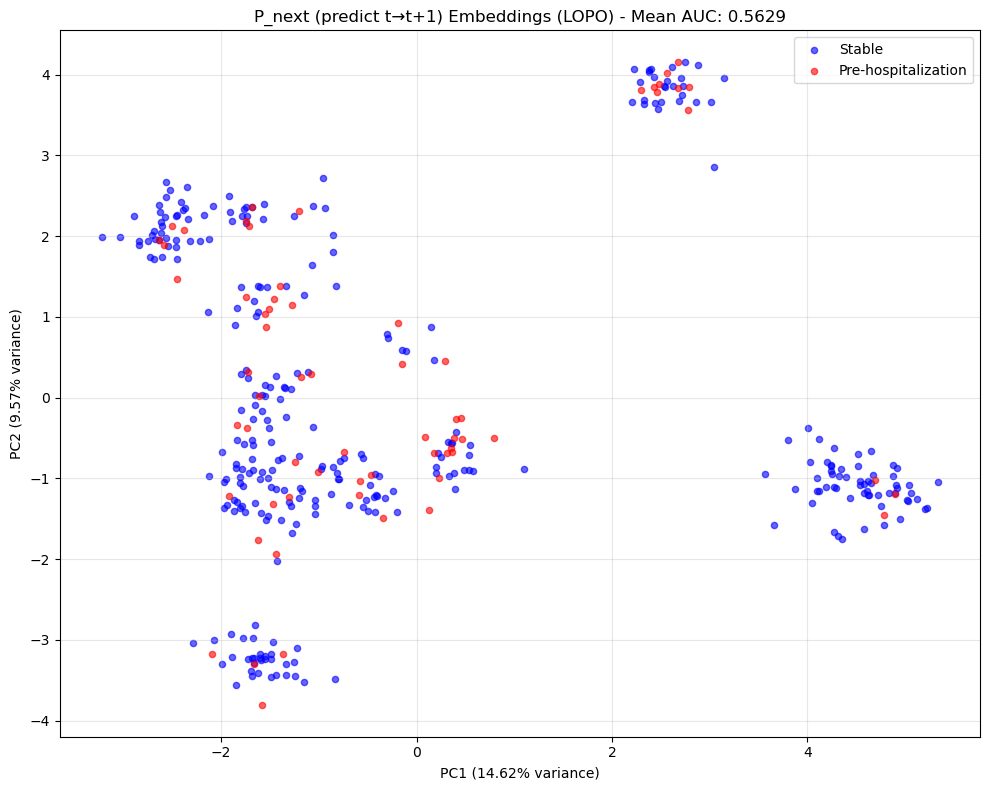

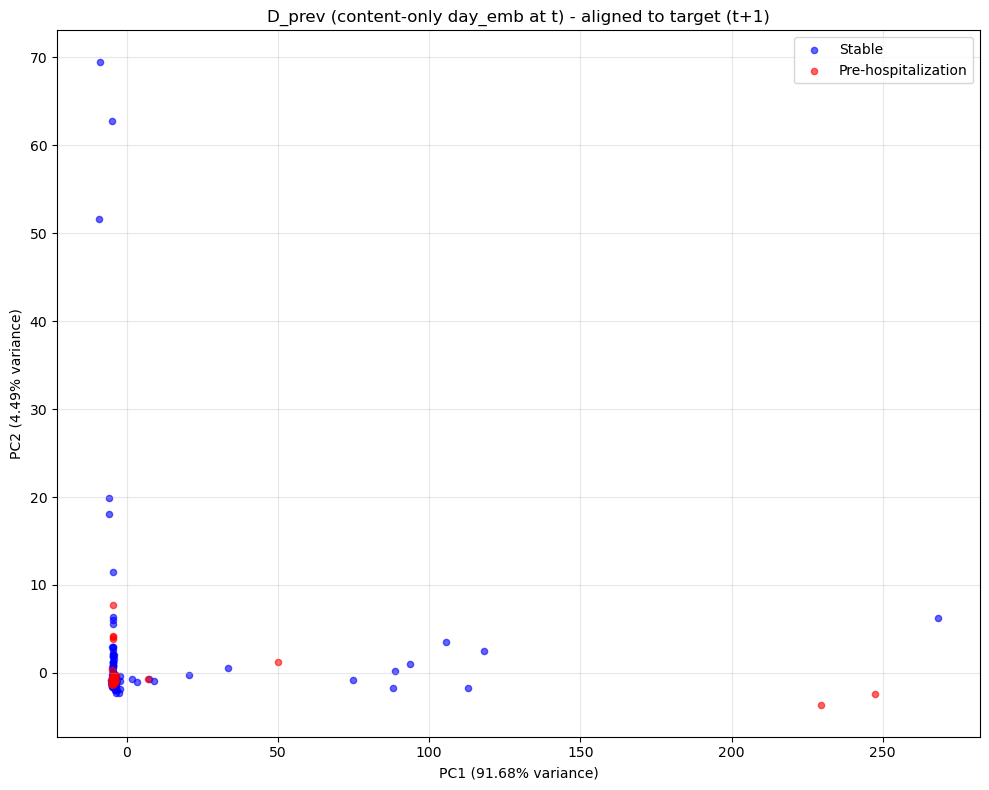

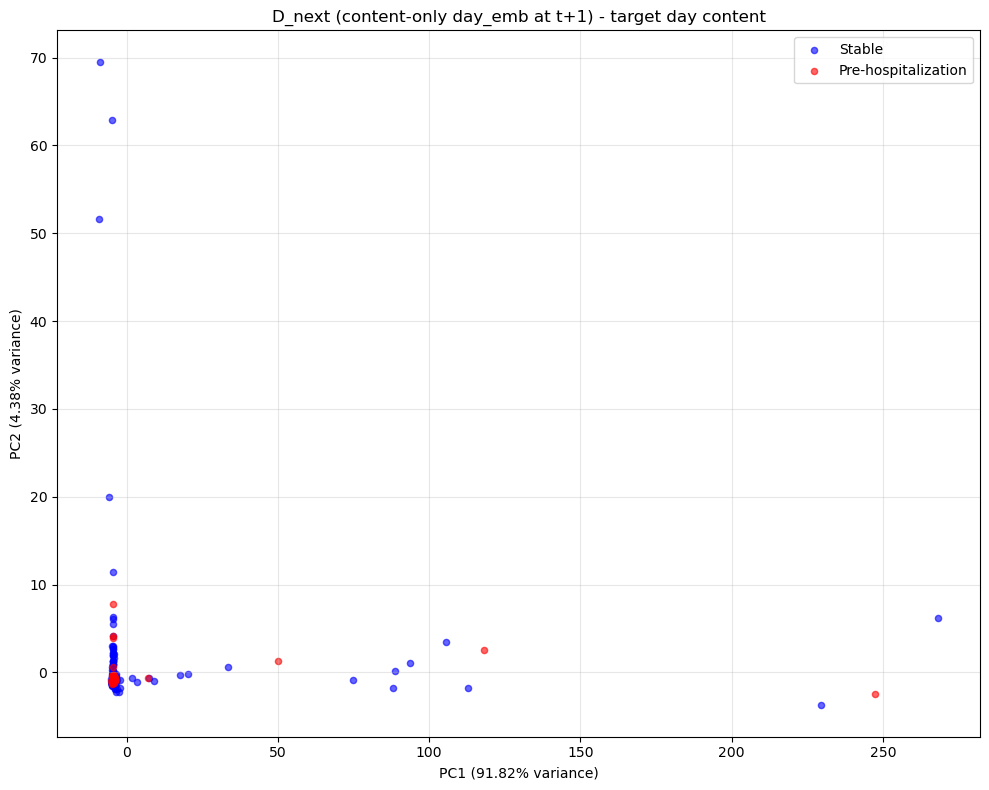

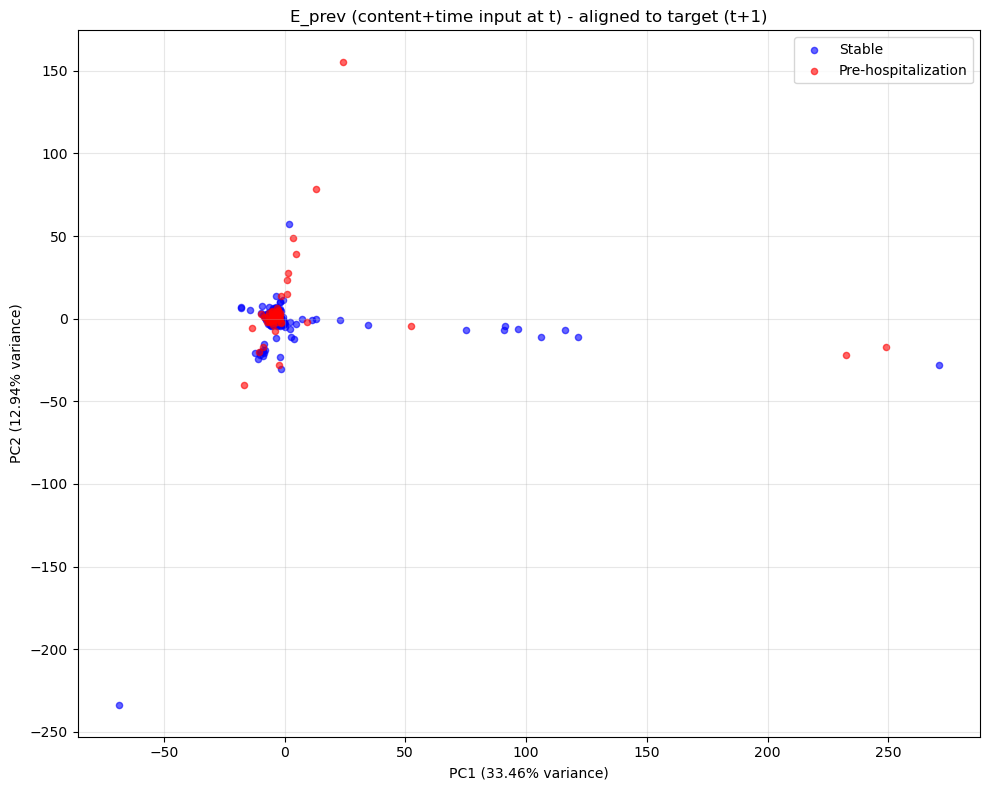

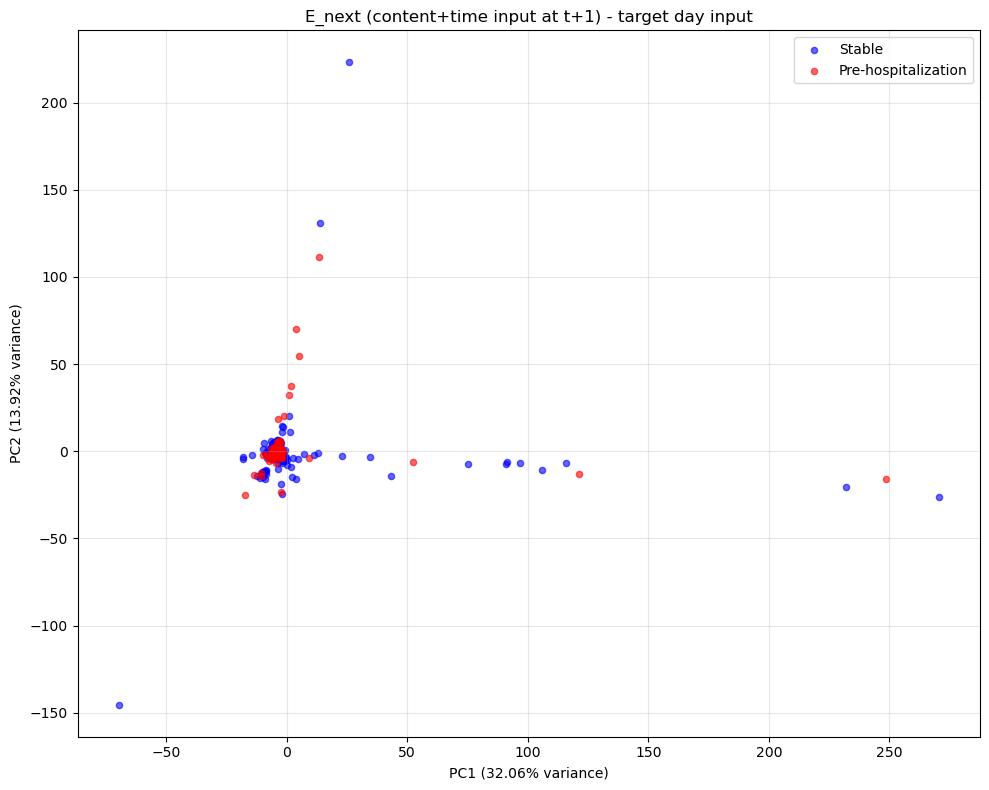

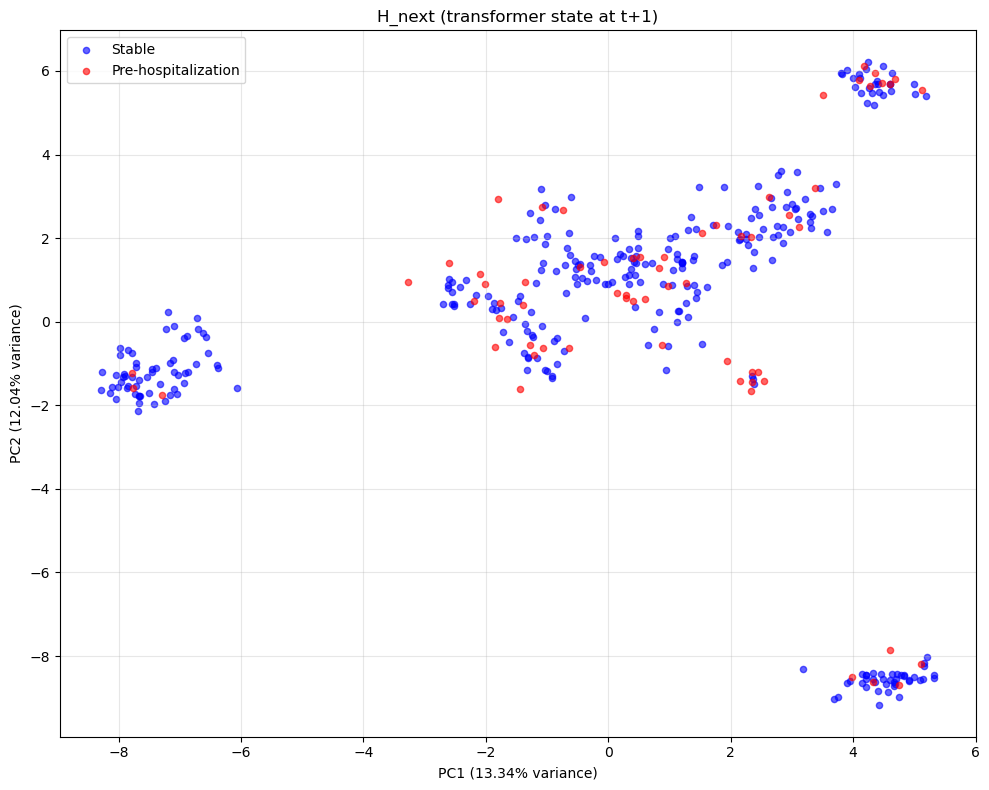


Training complete!
Final Mean ROC AUC: 0.5629 ± 0.2158
Embedding visualization saved in folder emb_vis


In [3]:
from train import (load_df, train_lopo)

DEVICE = "cuda" if (torch.cuda.is_available() and cfg.use_cuda) else "cpu"
print(f"Using device: {DEVICE}")

save_path = f"../embeddings_{cfc_name}/"
os.makedirs(save_path, exist_ok=True)
print(f"Saving embeddings plots to {save_path}")

print(f"Loading dataset...")
df, feature_cols = load_df(cfg.data_path)

# You’ll likely want to move S,C,stride,gap_days into cfg.py
results = train_lopo(
    df=df,
    feature_cols=feature_cols,
    chunk_hidden=cfg.chunk_hidden,
    day_dim=cfg.day_dim,
    gap_days=cfg.gap_days,
    max_T_emb=cfg.max_T_emb,
    dropout=cfg.dropout,
    batch_size=cfg.batch_size,
    num_epochs=cfg.num_epochs,
    learning_rate=cfg.learning_rate,
    weight_decay=cfg.weight_decay,
    device=DEVICE,
    save_path=save_path
)

print("\nTraining complete!")
print(f"Final Mean ROC AUC: {results['mean_auc']:.4f} ± {results['std_auc']:.4f}")
print("Embedding visualization saved in folder emb_vis")

In [59]:
from train import build_session_table

def compute_days_to_event(
    df: pd.DataFrame,
    *,
    patient_col: str = "patient_id",
    date_col: str = "date",
    label_col: str = "label",
    event_label: int = 1,
    allow_past_events: bool = True,
) -> pd.Series:
    """
    Compute days until the next event per (patient, date).

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe.
    patient_col : str
        Patient identifier column.
    date_col : str
        Date column (must be datetime).
    label_col : str
        Binary label column (event vs non-event).
    event_label : int
        Value in label_col that denotes an event.
    allow_past_events : bool
        If True, compute distance to nearest event (past or future).
        If False (default), only future events are considered.

    Returns
    -------
    pd.Series
        days_to_event aligned with df.index.
        NaN if no qualifying event exists.
    """
    if not np.issubdtype(df[date_col].dtype, np.datetime64):
        raise ValueError(f"{date_col} must be datetime64")

    df = df[[patient_col, date_col, label_col]].copy()
    df = df.sort_values([patient_col, date_col])

    days_to_event = pd.Series(index=df.index, dtype=float)

    for pid, g in df.groupby(patient_col):
        dates = g[date_col].values
        is_event = (g[label_col].values == event_label)
        event_dates = dates[is_event]

        if len(event_dates) == 0:
            days_to_event.loc[g.index] = np.nan
            continue

        for idx, d in zip(g.index, dates):
            if allow_past_events:
                delta = np.abs((event_dates - d).astype("timedelta64[W]").astype(int))
                days_to_event.loc[idx] = delta.min()
            else:
                future = event_dates[event_dates >= d]
                if len(future) == 0:
                    days_to_event.loc[idx] = np.nan
                else:
                    days_to_event.loc[idx] = (future[0] - d).astype("timedelta64[W]").astype(int)

    return days_to_event

df_ev = df.copy()

df_ev, sessions_ev = build_session_table(df_ev, feature_cols)

df_ev["to_event"] = compute_days_to_event(
    df_ev,
    patient_col="patient_short_id",
    date_col="date",
    label_col="label",
)

sessions_ev["to_event"] = compute_days_to_event(
    sessions_ev,
    patient_col="patient_short_id",
    date_col="session_start_time",
    label_col="session_label",
)

to_event = sessions_ev[sessions_ev["session_id"]!=1]["to_event"].values

In [63]:
from __future__ import annotations

from typing import Optional, Literal, Tuple, Dict, Any
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


def plot_embeddings_2d_flexible(
    embeddings: np.ndarray,
    *,
    labels: Optional[np.ndarray] = None,
    patient_ids: Optional[np.ndarray] = None,
    to_event: Optional[np.ndarray] = None,
    pred_score: Optional[np.ndarray] = None,
    cluster_ids: Optional[np.ndarray] = None,
    method: Literal["pca", "umap", "tsne"] = "pca",
    color_by: Literal["label", "to_event", "patient", "pred_score", "cluster"] = "label",
    title: str = "Embedding Space (2D)",
    save_path: Optional[str] = None,
    highlight_mask: Optional[np.ndarray] = None,
    annotate_indices: Optional[np.ndarray] = None,
    alpha: float = 0.65,
    s: int = 20,
    random_state: int = 42,
    reducer_kwargs: Optional[Dict[str, Any]] = None,
    ax: Optional[plt.Axes] = None,
    show_legend: bool = True,
    show_colorbar: bool = True,
) -> Tuple[plt.Figure, plt.Axes, np.ndarray, Any]:
    """
    Flexible 2D embedding plot with PCA/UMAP/t-SNE and multiple coloring modes.
    If `ax` is provided, plots into that axis (useful for subplot grids).
    """
    if embeddings.ndim != 2:
        raise ValueError(f"`embeddings` must be 2D, got shape {embeddings.shape}")

    n = embeddings.shape[0]
    reducer_kwargs = reducer_kwargs or {}

    # ---------- Reduce to 2D ----------
    method_l = method.lower()
    sc = None  # mappable for colorbar

    if method_l == "pca":
        reducer = PCA(n_components=2, random_state=random_state, **reducer_kwargs)
        emb_2d = reducer.fit_transform(embeddings)
        xlab = f"PC1 ({reducer.explained_variance_ratio_[0]:.2%} var)"
        ylab = f"PC2 ({reducer.explained_variance_ratio_[1]:.2%} var)"

    elif method_l == "umap":
        try:
            import umap  # type: ignore
        except ImportError as e:
            raise ImportError(
                "UMAP selected but `umap-learn` is not installed. "
                "Install via: pip install umap-learn"
            ) from e

        defaults = dict(n_neighbors=15, min_dist=0.1, metric="cosine", random_state=random_state)
        defaults.update(reducer_kwargs)
        reducer = umap.UMAP(n_components=2, **defaults)
        emb_2d = reducer.fit_transform(embeddings)
        xlab, ylab = "UMAP-1", "UMAP-2"

    elif method_l == "tsne":
        from sklearn.manifold import TSNE
        defaults = dict(
            n_components=2, perplexity=30, init="pca",
            learning_rate="auto", random_state=random_state
        )
        defaults.update(reducer_kwargs)
        reducer = TSNE(**defaults)
        emb_2d = reducer.fit_transform(embeddings)
        xlab, ylab = "t-SNE-1", "t-SNE-2"

    else:
        raise ValueError(f"Unknown method: {method}. Choose from 'pca', 'umap', 'tsne'.")

    # ---------- Ax handling ----------
    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 8))
        created_fig = True
    else:
        fig = ax.figure

    # ---------- Build color vector ----------
    def _require(arr: Optional[np.ndarray], name: str) -> np.ndarray:
        if arr is None:
            raise ValueError(f"`color_by='{color_by}'` requires `{name}` to be provided.")
        arr = np.asarray(arr)
        if arr.shape[0] != n:
            raise ValueError(f"`{name}` must have length {n}, got {arr.shape[0]}")
        return arr

    # Clear axis if reusing
    ax.cla()

    if color_by == "label":
        y = _require(labels, "labels")
        uniq = np.unique(y)

        if set(uniq.tolist()) == {0, 1}:
            cmap = {0: "blue", 1: "red"}
            name_map = {0: "Stable", 1: "Pre-hospitalization"}
        else:
            cmap = None
            name_map = {v: f"Class {v}" for v in uniq}

        for v in uniq:
            m = y == v
            ax.scatter(
                emb_2d[m, 0], emb_2d[m, 1],
                c=(cmap[v] if cmap else None),
                label=name_map.get(v, str(v)),
                alpha=alpha,
                s=s,
            )
        if show_legend:
            ax.legend(fontsize=8)

    elif color_by == "to_event":
        v = _require(to_event, "to_event").astype(float)
        sc = ax.scatter(emb_2d[:, 0], emb_2d[:, 1], c=v, alpha=alpha, s=s)
        if show_colorbar and created_fig:
            cb = fig.colorbar(sc, ax=ax)
            cb.set_label("Time to event")

    elif color_by == "pred_score":
        v = _require(pred_score, "pred_score").astype(float)
        sc = ax.scatter(emb_2d[:, 0], emb_2d[:, 1], c=v, alpha=alpha, s=s)
        if show_colorbar and created_fig:
            cb = fig.colorbar(sc, ax=ax)
            cb.set_label("Predicted score")

    elif color_by == "patient":
        v = _require(patient_ids, "patient_ids")
        _, v_int = np.unique(v, return_inverse=True)
        sc = ax.scatter(emb_2d[:, 0], emb_2d[:, 1], c=v_int, alpha=alpha, s=s)
        if show_colorbar and created_fig:
            cb = fig.colorbar(sc, ax=ax)
            cb.set_label("Patient (encoded)")

    elif color_by == "cluster":
        v = _require(cluster_ids, "cluster_ids")
        sc = ax.scatter(emb_2d[:, 0], emb_2d[:, 1], c=v, alpha=alpha, s=s)
        if show_colorbar and created_fig:
            cb = fig.colorbar(sc, ax=ax)
            cb.set_label("Cluster id")

    else:
        raise ValueError(f"Unknown color_by: {color_by}")

    # ---------- Optional highlight ----------
    if highlight_mask is not None:
        hm = np.asarray(highlight_mask).astype(bool)
        if hm.shape[0] != n:
            raise ValueError(f"`highlight_mask` must have length {n}, got {hm.shape[0]}")
        ax.scatter(
            emb_2d[hm, 0], emb_2d[hm, 1],
            facecolors="none",
            edgecolors="black",
            linewidths=1.2,
            s=max(s * 2, 30),
            alpha=1.0,
        )

    # ---------- Optional annotate ----------
    if annotate_indices is not None:
        idx = np.asarray(annotate_indices).astype(int)
        for i in idx:
            if 0 <= i < n:
                ax.annotate(str(i), (emb_2d[i, 0], emb_2d[i, 1]), fontsize=8, alpha=0.8)

    ax.set_xlabel(xlab, fontsize=8)
    ax.set_ylabel(ylab, fontsize=8)
    ax.set_title(title, fontsize=9)
    ax.grid(True, alpha=0.3)

    if created_fig:
        plt.tight_layout()
        if save_path:
            fig.savefig(save_path, dpi=300, bbox_inches="tight")

    return fig, ax, emb_2d, reducer, sc


In [64]:
results.keys()

dict_keys(['per_patient_auc', 'mean_auc', 'std_auc', 'D_prev', 'D_next', 'E_prev', 'E_next', 'H_next', 'P_next', 'labels', 'patient_ids'])

In [6]:
H_next = results["H_next"]
P_next = results["P_next"]
labels = results["labels"]
patient_ids = results["patient_ids"]

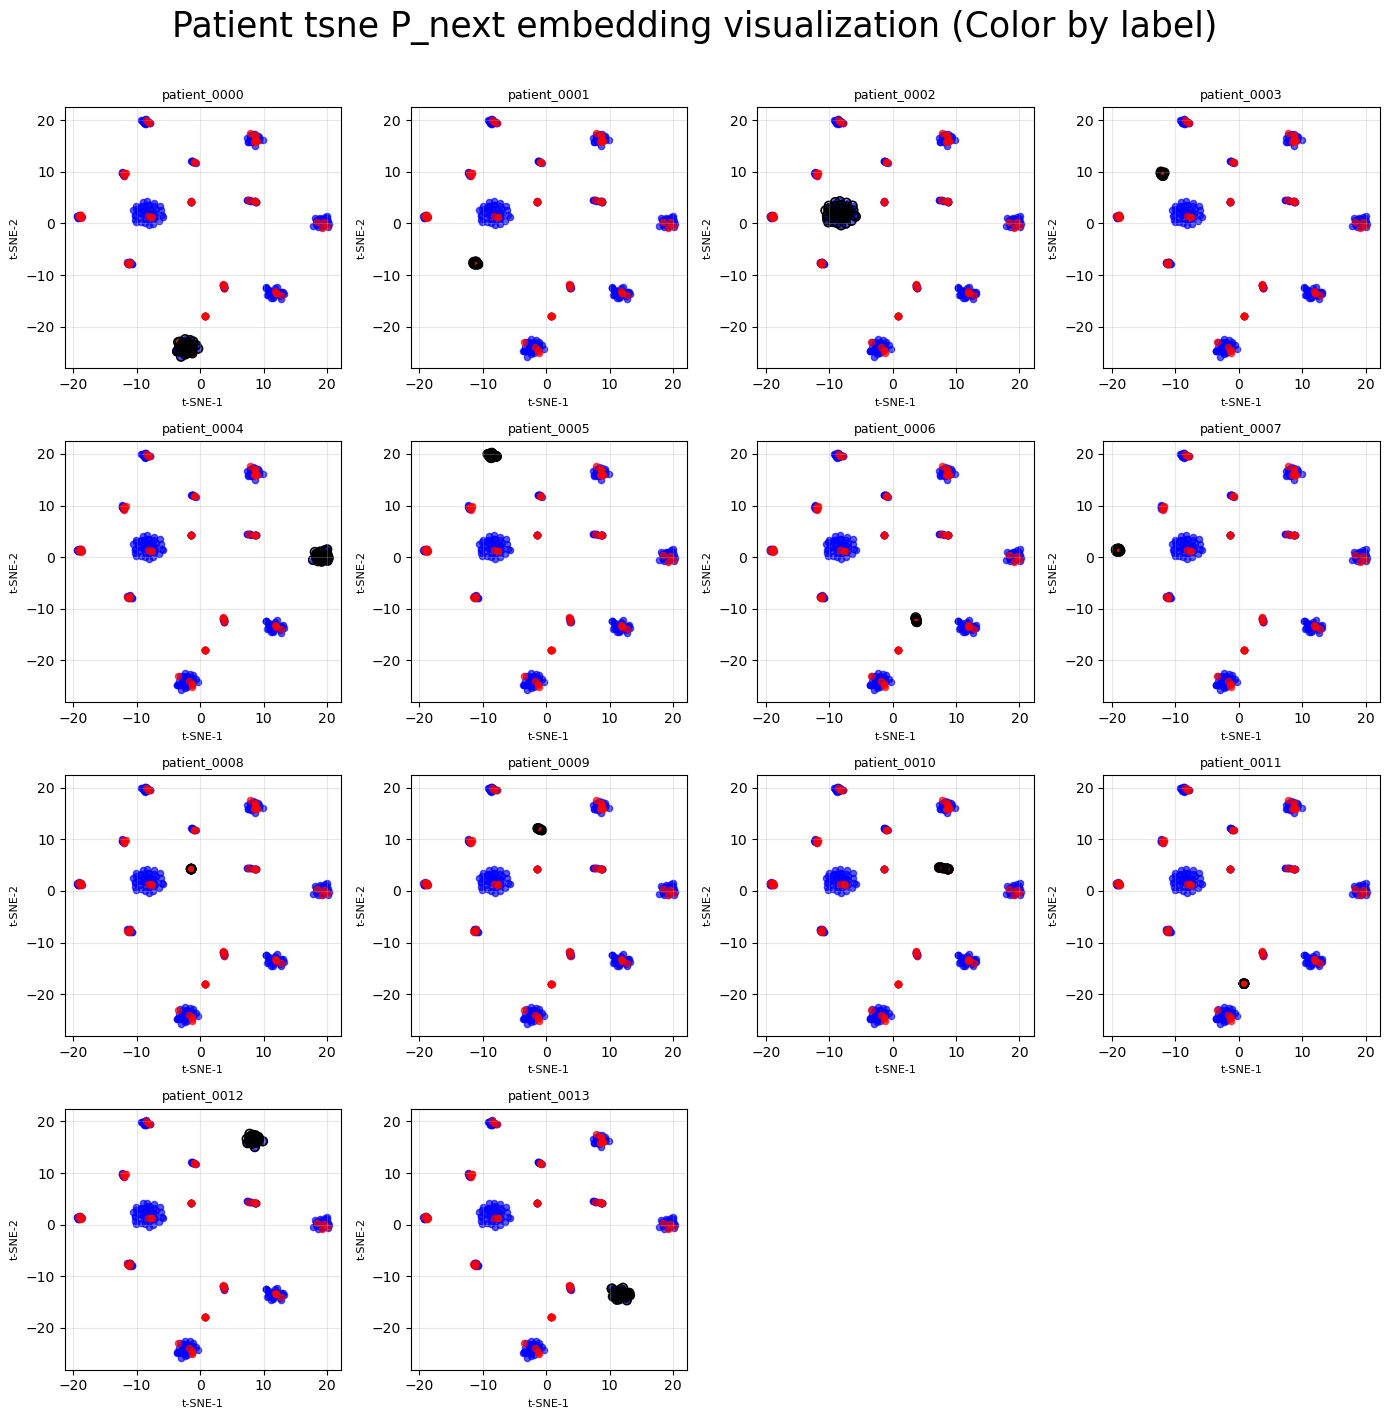

In [ ]:
plotting_method = "tsne"
color_by = "label"

unique_pids = sorted(list(set(patient_ids)))

nrows, ncols = 4, 4
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 14))
axes = axes.ravel()

for i, pid in enumerate(unique_pids[: nrows * ncols]):
    highlight = (patient_ids == pid)

    plot_embeddings_2d_flexible(
        H_next,
        labels=labels,
        patient_ids=patient_ids,
        method=plotting_method,
        color_by=color_by,
        highlight_mask=highlight,
        title=f"{pid}",
        ax=axes[i],
        show_legend=False,      # avoids clutter
        show_colorbar=False,    # avoid per-subplot colorbars
    )

# Hide any unused subplots
for j in range(i + 1, nrows * ncols):
    axes[j].axis("off")

plt.suptitle(f"Patient {plotting_method} H_next embedding visualization (Color by {color_by})", fontsize=25, y=1.01)
plt.tight_layout()
plt.show()


C:\Users\castr\AppData\Local\Temp\ipykernel_18296\2451124516.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.90])


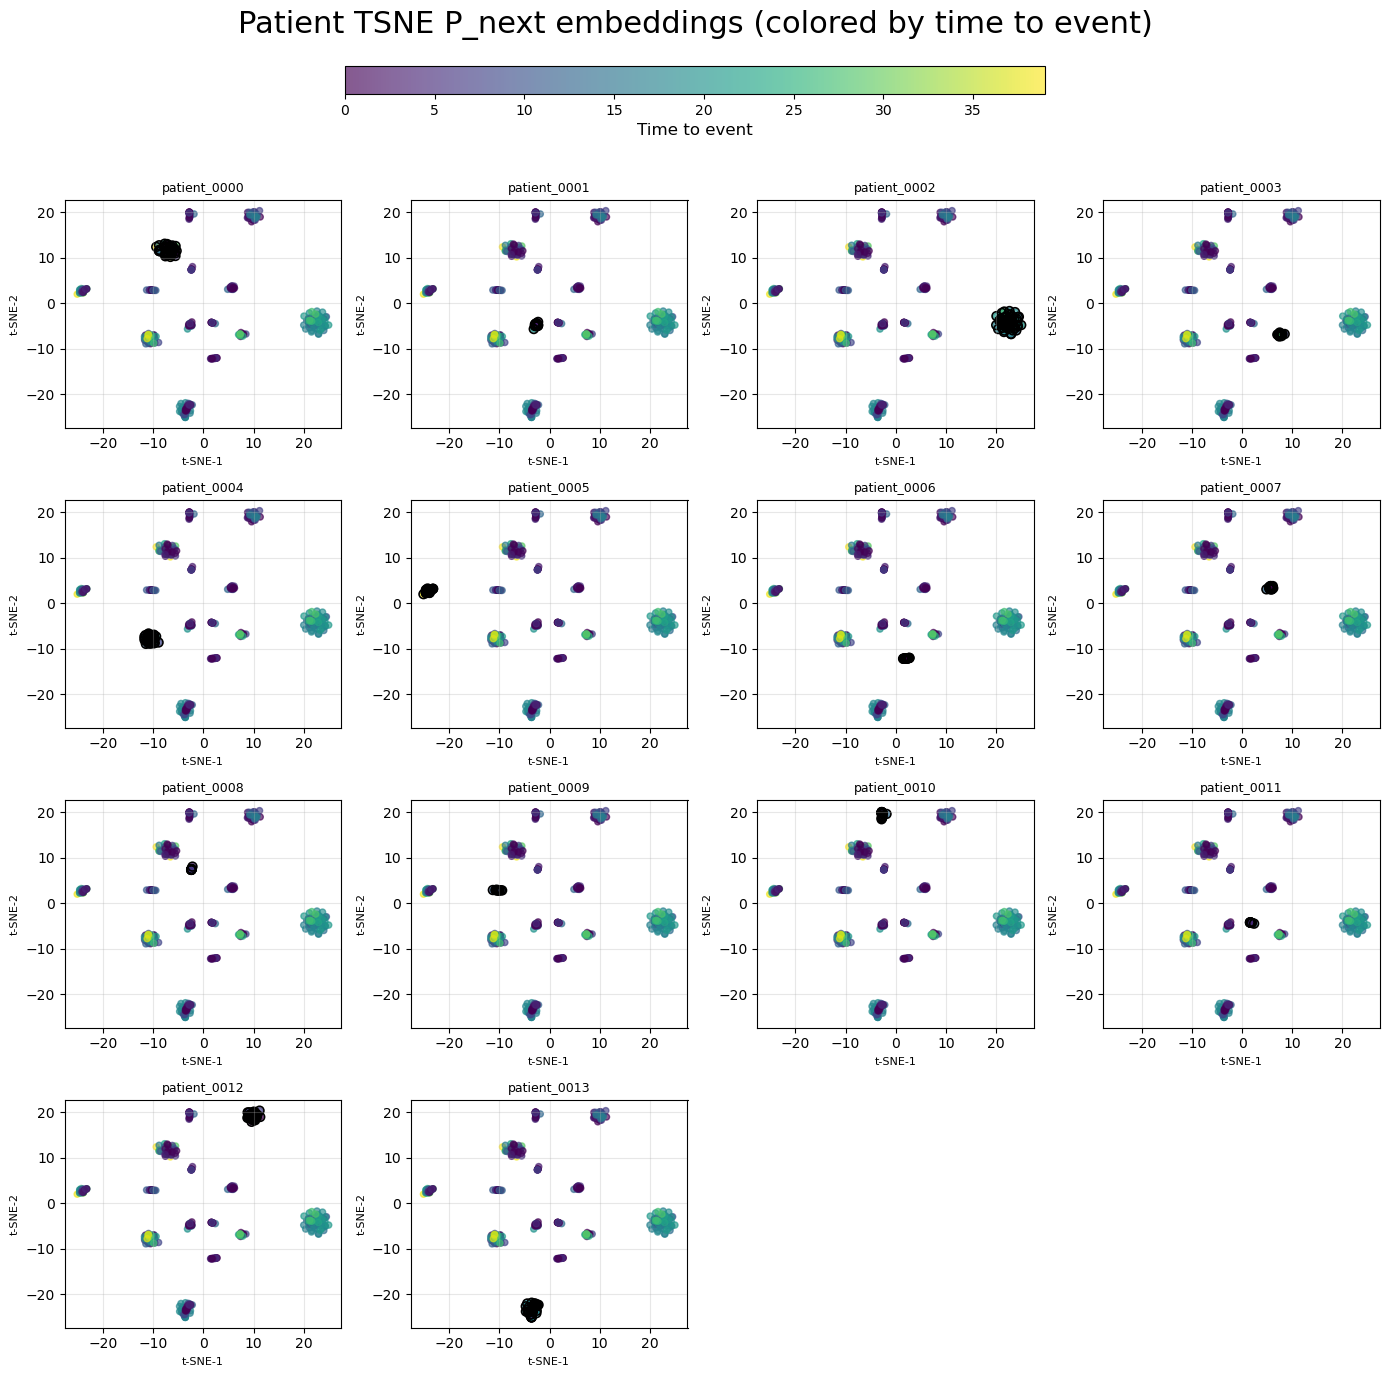

In [73]:
plotting_method = "tsne"
color_by = "to_event"

unique_pids = sorted(list(set(patient_ids)))

nrows, ncols = 4, 4
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 14))
axes = axes.ravel()

sc_for_colorbar = None  # will grab once

for i, pid in enumerate(unique_pids[: nrows * ncols]):
    highlight = (patient_ids == pid)

    _, _, _, _, sc = plot_embeddings_2d_flexible(
        P_next,
        labels=labels,
        patient_ids=patient_ids,
        to_event=to_event, 
        method=plotting_method,
        color_by="to_event",
        highlight_mask=highlight,
        title=f"{pid}",
        ax=axes[i],
        show_legend=False,
        show_colorbar=False,
    )

    # save one representative mappable
    if sc_for_colorbar is None and sc is not None:
        sc_for_colorbar = sc

# Hide unused subplots
for j in range(i + 1, nrows * ncols):
    axes[j].axis("off")

plt.suptitle(
    f"Patient {plotting_method.upper()} P_next embeddings (colored by time to event)",
    fontsize=22,
    y=0.98,
)

# colorbar below title
if sc_for_colorbar is not None:
    cax = fig.add_axes([0.25, 0.92, 0.5, 0.02])
    cbar = fig.colorbar(sc_for_colorbar, cax=cax, orientation="horizontal")
    cbar.set_label("Time to event", fontsize=12)

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()


ValueError: not enough values to unpack (expected 5, got 4)

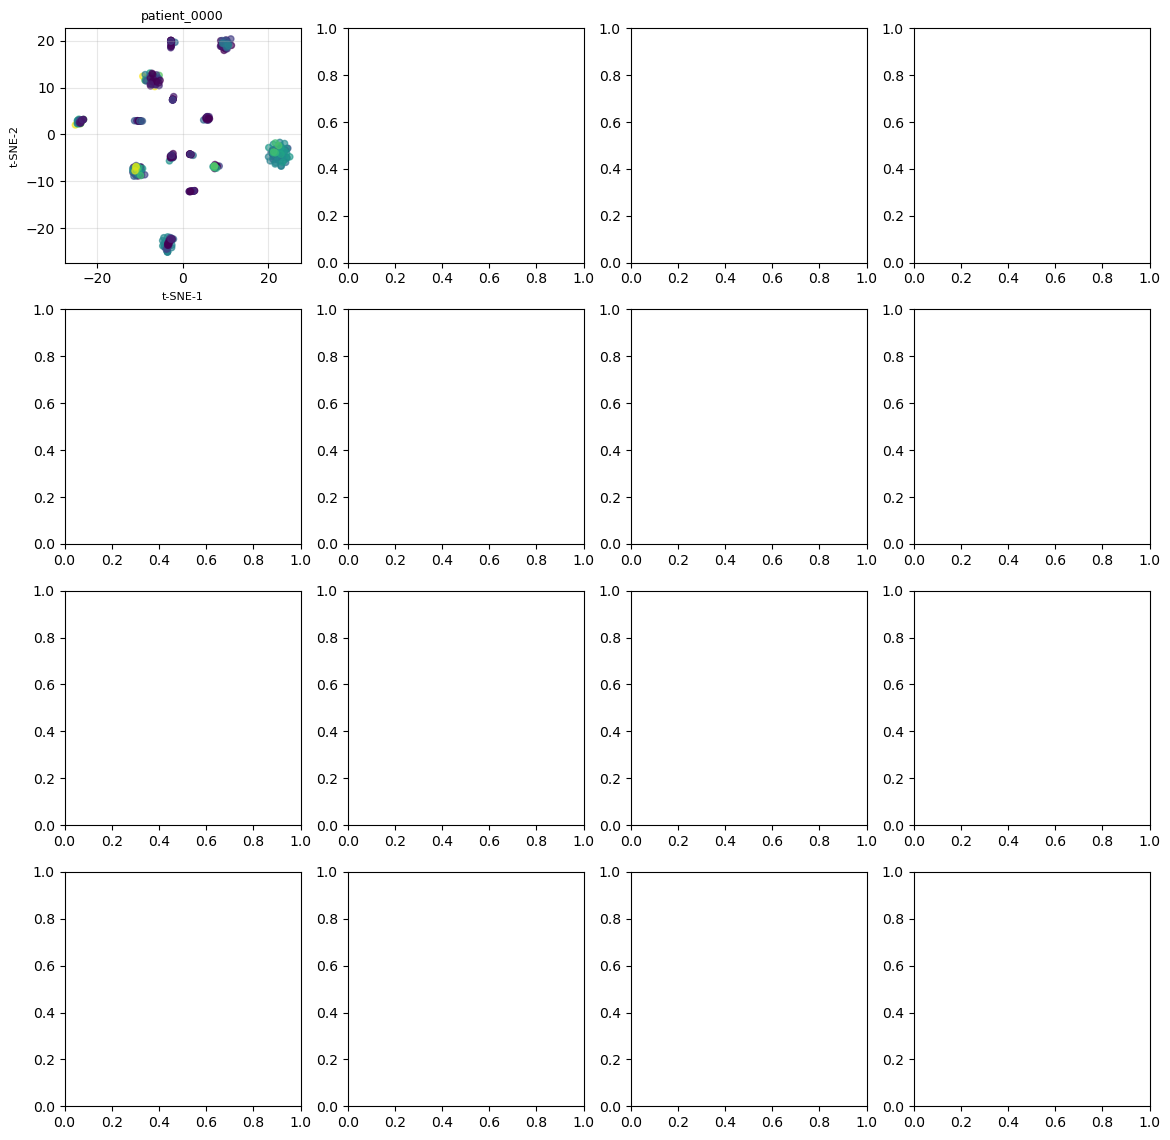

In [61]:
plotting_method = "tsne"
color_by = "to_event"

unique_pids = sorted(list(set(patient_ids)))

nrows, ncols = 4, 4
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 14))
axes = axes.ravel()

sc_for_colorbar = None  # will grab once

for i, pid in enumerate(unique_pids[: nrows * ncols]):
    highlight = (patient_ids == pid)

    _, _, _, _, sc = plot_embeddings_2d_flexible(
        P_next,
        labels=labels,
        patient_ids=patient_ids,
        to_event=to_event,   # <- name must match function
        method=plotting_method,
        color_by=color_by,
        title=f"{pid}",
        ax=axes[i],
        show_legend=False,
        show_colorbar=False,
    )

    # save one representative mappable
    if sc_for_colorbar is None and sc is not None:
        sc_for_colorbar = sc

# Hide unused subplots
for j in range(i + 1, nrows * ncols):
    axes[j].axis("off")

# ---- Shared colorbar ----
if sc_for_colorbar is not None:
    cbar = fig.colorbar(
        sc_for_colorbar,
        ax=axes[: i + 1],
        shrink=0.8,
        pad=0.02,
    )
    cbar.set_label("Time to event (weeks)", fontsize=12)

plt.suptitle(
    f"Patient {plotting_method.upper()} P_next embeddings (colored by time to event)",
    fontsize=22,
    y=1.02,
)

plt.tight_layout()
plt.show()
